In [1]:
import plotnine as p
import polars as pl

In [16]:
df = pl.read_csv('250517.results.csv')

In [26]:
pl.Config.set_tbl_rows(100)
df

model,test_set,reconstruction_error
cat,str,f64
"""liver_model""","""brain_test""",36707.863
"""liver_model""","""liver_test""",3688.7688
"""brain_model""","""brain_test""",7803.1816
"""brain_model""","""liver_test""",10803.492
"""linear_merged_model""","""brain_test""",15792.342
"""linear_merged_model""","""liver_test""",7397.1396
"""nuslerp_merged_model""","""brain_test""",15792.296
"""nuslerp_merged_model""","""liver_test""",7397.611
"""combined_10e_model""","""brain_test""",7833.823


In [17]:
df['model'].unique()

model
str
"""combined_20e_model"""
"""nuslerp_merged_model"""
"""brain_model"""
"""liver_model"""
"""combined_10e_model"""
"""linear_merged_model"""


/var/folders/7r/l13t20c12ps45_9nh3wwbplm0000gn/T/ipykernel_7452/2743815001.py:26: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figure1.png


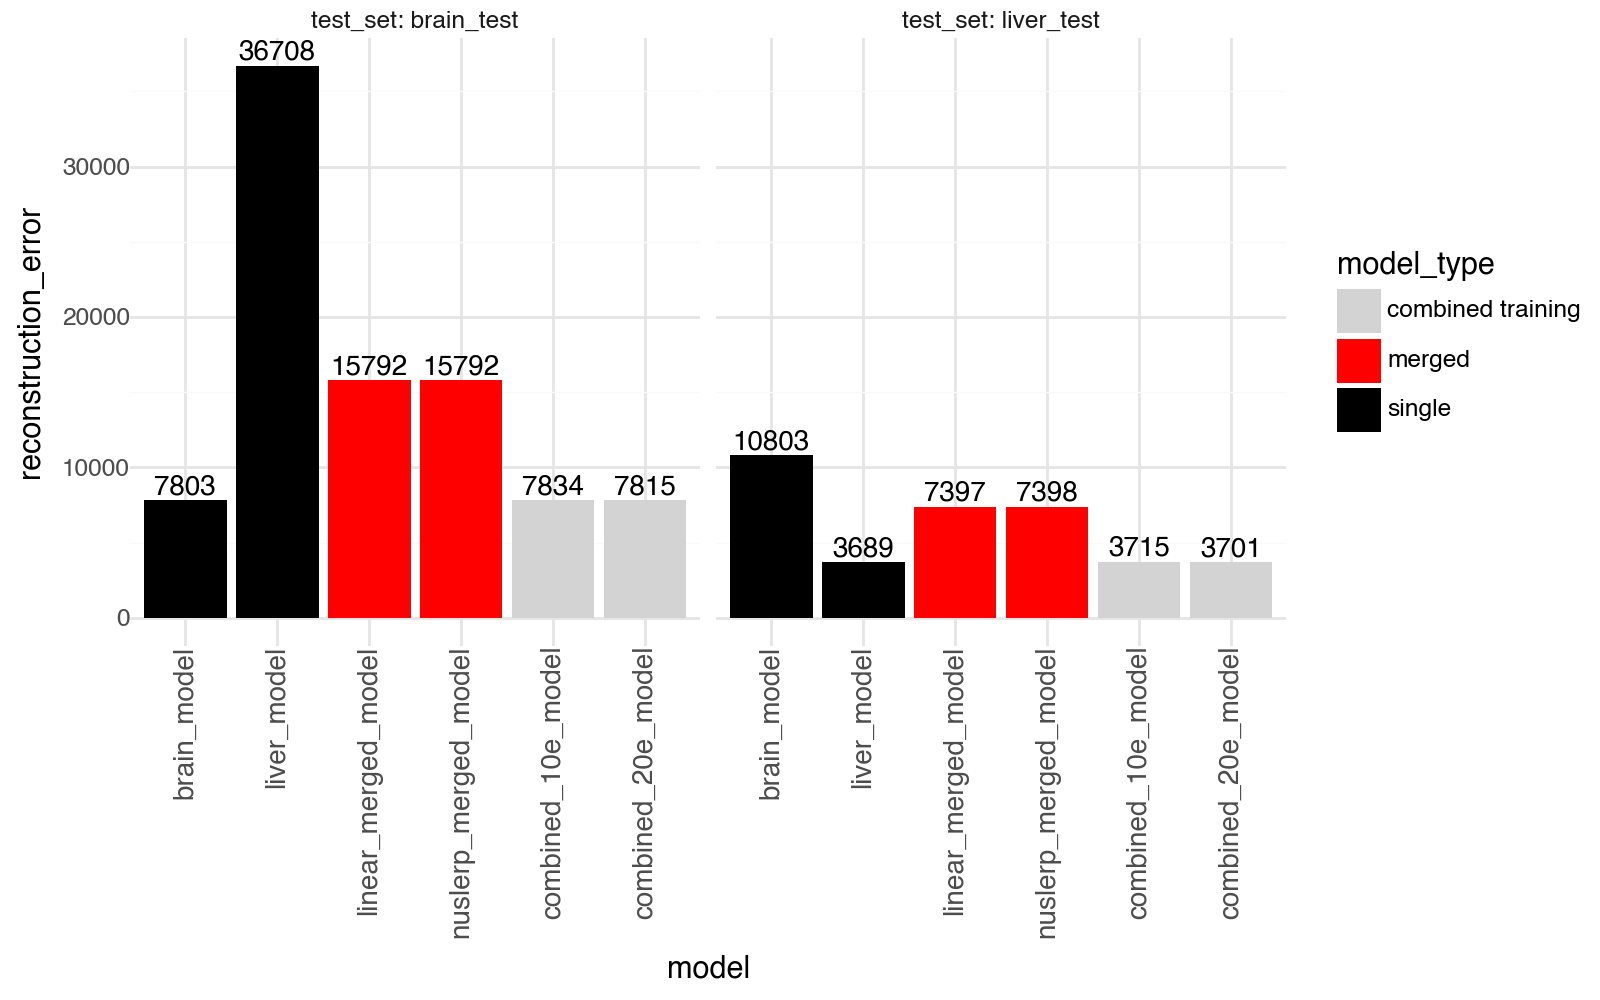

In [51]:
order = [
    "liver_model",
    "brain_model",
    "linear_merged_model",
    "nuslerp_merged_model",
    "combined_10e_model",
    "combined_20e_model",
]

with pl.StringCache():
    # register the order in the cache
    pl.Series(order).cast(pl.Categorical)
    # cast your df column under that same cache
    df = df.with_columns(
        pl.col("model").cast(pl.Categorical("physical"))
    )

    def categorize_model(model_name: str) -> str:
        if "merged" in model_name:
            return "merged"
        elif "combined" in model_name:
            return "combined training"
        else:
            return "single"

    df = df.with_columns(
        pl.col("model").map_elements(categorize_model).alias("model_type")
    )

# now sorts in your custom order
df = df.sort("model")

p_ = (
    p.ggplot(df)
    + p.aes(x = 'model', y = 'reconstruction_error', fill = 'model_type')
    + p.geom_bar(stat = p.stat_identity())
    + p.geom_text(
        p.aes(label='round(reconstruction_error).astype(int)'),
        va='bottom',
        angle=0,
        size=10
    )
    + p.scale_fill_manual({
        'single': 'black',
        'merged': 'red',
        'combined training': 'lightgrey'
    })
    + p.theme_minimal()
    + p.theme(figure_size = (8, 5))
    + p.facet_grid('. ~ test_set', labeller = 'label_both')
    + p.theme(axis_text_x = p.element_text(angle = 90, size = 10))
)

p_.save('figure1.png', dpi = 300)

p_